# Mini-Capstone Project 1: E-Commerce Health Check (Olist)

This notebook integrates Python, pandas/NumPy, SQLite SQL, EDA, and statistics on the Olist e-commerce dataset.

## 1) Imports and setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'dataset'
DB_PATH = BASE_DIR / 'olist_capstone.db'

print('Base dir:', BASE_DIR)
print('Data dir exists:', DATA_DIR.exists())
print('DB path:', DB_PATH)

Matplotlib is building the font cache; this may take a moment.


Base dir: c:\Users\aftabsss\OneDrive\Desktop\jigi sem 1 2 3\DS Project
Data dir exists: True
DB path: c:\Users\aftabsss\OneDrive\Desktop\jigi sem 1 2 3\DS Project\olist_capstone.db


## 2) Load CSV files

In [2]:
customers = pd.read_csv(DATA_DIR / 'olist_customers_dataset.csv')
orders = pd.read_csv(DATA_DIR / 'olist_orders_dataset.csv')
order_items = pd.read_csv(DATA_DIR / 'olist_order_items_dataset.csv')
products = pd.read_csv(DATA_DIR / 'olist_products_dataset.csv')
order_reviews = pd.read_csv(DATA_DIR / 'olist_order_reviews_dataset.csv')
order_payments = pd.read_csv(DATA_DIR / 'olist_order_payments_dataset.csv')
sellers = pd.read_csv(DATA_DIR / 'olist_sellers_dataset.csv')
category_translation = pd.read_csv(DATA_DIR / 'product_category_name_translation.csv')

print('Loaded all core files successfully.')

Loaded all core files successfully.


## 3) Initial inspection (shape, dtypes, missing values)

In [3]:
tables = {
    'customers': customers,
    'orders': orders,
    'order_items': order_items,
    'products': products,
    'order_reviews': order_reviews,
    'order_payments': order_payments,
    'sellers': sellers,
    'category_translation': category_translation,
}

summary_rows = []
for name, df in tables.items():
    summary_rows.append({
        'table': name,
        'rows': df.shape[0],
        'cols': df.shape[1],
        'missing_values': int(df.isna().sum().sum())
    })

summary_df = pd.DataFrame(summary_rows).sort_values('rows', ascending=False)
summary_df

,table,rows,cols,missing_values
2,order_items,112650,7,0
5,order_payments,103886,5,0
1,orders,99441,8,4908
0,customers,99441,5,0
4,order_reviews,99224,7,145903
3,products,32951,9,2448
6,sellers,3095,4,0
7,category_translation,71,2,0


In [4]:
for name, df in tables.items():
    print(f'\n{name.upper()}')
    print(df.dtypes.head(10))
    print('Top missing columns:')
    print(df.isna().sum().sort_values(ascending=False).head(5))


CUSTOMERS
customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object
Top missing columns:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

ORDERS
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object
Top missing columns:
order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
order_id                            0
order_purchase_timestamp            0
dtype: int64

ORDER_ITEMS
order_id                   str
order_item_id            int64
prod

## 4) Data cleaning

In [5]:
orders_clean = orders.copy()
order_reviews_clean = order_reviews.copy()
order_items_clean = order_items.copy()
products_clean = products.copy()
customers_clean = customers.copy()
order_payments_clean = order_payments.copy()
sellers_clean = sellers.copy()
category_translation_clean = category_translation.copy()

# Parse date columns
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
]
for col in date_cols:
    orders_clean[col] = pd.to_datetime(orders_clean[col], errors='coerce')

review_date_cols = ['review_creation_date', 'review_answer_timestamp']
for col in review_date_cols:
    order_reviews_clean[col] = pd.to_datetime(order_reviews_clean[col], errors='coerce')

# Handle missing review_score with median imputation
review_median = order_reviews_clean['review_score'].median()
order_reviews_clean['review_score'] = order_reviews_clean['review_score'].fillna(review_median)

# Remove exact duplicates
orders_clean = orders_clean.drop_duplicates()
order_items_clean = order_items_clean.drop_duplicates()
order_reviews_clean = order_reviews_clean.drop_duplicates()

print('Cleaning complete.')
print('orders duplicates on order_id:', orders_clean.duplicated(subset=['order_id']).sum())
print('review_score nulls after fill:', order_reviews_clean['review_score'].isna().sum())

Cleaning complete.
orders duplicates on order_id: 0
review_score nulls after fill: 0


## 5) Feature engineering

In [6]:
# Per-order item totals
order_items_clean['item_total_value'] = order_items_clean['price'] + order_items_clean['freight_value']

order_value = (
    order_items_clean.groupby('order_id', as_index=False)['item_total_value']
    .sum()
    .rename(columns={'item_total_value': 'order_value'})
)

orders_enriched = orders_clean.merge(order_value, on='order_id', how='left')

# Shipping duration in days
orders_enriched['shipping_days'] = (
    orders_enriched['order_delivered_customer_date'] - orders_enriched['order_purchase_timestamp']
).dt.total_seconds() / (24 * 3600)

orders_enriched['is_weekend'] = orders_enriched['order_purchase_timestamp'].dt.dayofweek >= 5
orders_enriched[['order_id', 'order_value', 'shipping_days', 'is_weekend']].head()

,order_id,order_value,shipping_days,is_weekend
0,e481f51cbdc54678b7cc49136f2d6af7,38.71,8.436574,False
1,53cdb2fc8bc7dce0b6741e2150273451,141.46,13.782037,False
2,47770eb9100c2d0c44946d9cf07ec65d,179.12,9.394213,False
3,949d5b44dbf5de918fe9c16f97b45f8a,72.20,13.208750,True
4,ad21c59c0840e6cb83a9ceb5573f8159,28.62,2.873877,False


## 6) Load cleaned tables into SQLite

In [7]:
with sqlite3.connect(DB_PATH) as conn:
    customers_clean.to_sql('customers', conn, if_exists='replace', index=False)
    orders_enriched.to_sql('orders', conn, if_exists='replace', index=False)
    order_items_clean.to_sql('order_items', conn, if_exists='replace', index=False)
    products_clean.to_sql('products', conn, if_exists='replace', index=False)
    order_reviews_clean.to_sql('order_reviews', conn, if_exists='replace', index=False)
    order_payments_clean.to_sql('order_payments', conn, if_exists='replace', index=False)
    sellers_clean.to_sql('sellers', conn, if_exists='replace', index=False)
    category_translation_clean.to_sql('product_category_name_translation', conn, if_exists='replace', index=False)

print('SQLite database created and populated:', DB_PATH)

SQLite database created and populated: c:\Users\aftabsss\OneDrive\Desktop\jigi sem 1 2 3\DS Project\olist_capstone.db


## 7) SQL business queries (JOIN, GROUP BY, CTE, window function)

In [8]:
def run_sql(query: str) -> pd.DataFrame:
    with sqlite3.connect(DB_PATH) as conn:
        return pd.read_sql_query(query, conn)

# Query 1: Top 10 products by revenue (JOIN + GROUP BY)
q1 = '''
SELECT
    oi.product_id,
    ROUND(SUM(oi.price + oi.freight_value), 2) AS revenue,
    COUNT(DISTINCT oi.order_id) AS order_count
FROM order_items oi
GROUP BY oi.product_id
ORDER BY revenue DESC
LIMIT 10;
'''
run_sql(q1)

,product_id,revenue,order_count
0,bb50f2e236e5eea0100680137654686c,67606.10,187
1,d1c427060a0f73f6b889a5c7c61f2ac4,60976.03,323
2,6cdd53843498f92890544667809f1595,59093.99,151
3,99a4788cb24856965c36a24e339b6058,51071.60,467
4,d6160fb7873f184099d9bc95e30376af,50326.18,35
5,3dd2a17168ec895c781a9191c1e95ad7,48212.22,255
6,aca2eb7d00ea1a7b8ebd4e68314663af,44820.76,431
7,5f504b3a1c75b73d6151be81eb05bdc9,41725.81,63
8,25c38557cf793876c5abdd5931f922db,40311.95,38
9,53b36df67ebb7c41585e8d54d6772e08,39957.93,306


In [9]:
# Query 2: Repeat customer rate
q2 = '''
WITH customer_order_counts AS (
    SELECT
        o.customer_id,
        COUNT(DISTINCT o.order_id) AS n_orders
    FROM orders o
    GROUP BY o.customer_id
)
SELECT
    ROUND(100.0 * SUM(CASE WHEN n_orders > 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS repeat_customer_rate_pct
FROM customer_order_counts;
'''
run_sql(q2)

,repeat_customer_rate_pct
0,0.0


In [10]:
# Query 3: Monthly order trends
q3 = '''
SELECT
    strftime('%Y-%m', order_purchase_timestamp) AS year_month,
    COUNT(*) AS total_orders,
    ROUND(AVG(order_value), 2) AS avg_order_value
FROM orders
GROUP BY year_month
ORDER BY year_month;
'''
run_sql(q3).head(15)

,year_month,total_orders,avg_order_value
0,2016-09,4,118.25
1,2016-10,324,184.44
2,2016-12,1,19.62
3,2017-01,800,173.88
4,2017-02,1780,165.19
5,2017-03,2682,163.59
6,2017-04,2404,172.49
7,2017-05,3700,160.16
8,2017-06,3245,156.35
9,2017-07,4026,147.39


In [11]:
# Query 4: Payment type contribution
q4 = '''
SELECT
    payment_type,
    COUNT(*) AS payment_records,
    ROUND(SUM(payment_value), 2) AS total_payment_value
FROM order_payments
GROUP BY payment_type
ORDER BY total_payment_value DESC;
'''
run_sql(q4)

,payment_type,payment_records,total_payment_value
0,credit_card,76795,12542084.19
1,boleto,19784,2869361.27
2,voucher,5775,379436.87
3,debit_card,1529,217989.79
4,not_defined,3,0.00


In [12]:
# Query 5: Window function for running monthly revenue
q5 = '''
WITH monthly_revenue AS (
    SELECT
        strftime('%Y-%m', order_purchase_timestamp) AS year_month,
        SUM(order_value) AS monthly_revenue
    FROM orders
    GROUP BY strftime('%Y-%m', order_purchase_timestamp)
)
SELECT
    year_month,
    ROUND(monthly_revenue, 2) AS monthly_revenue,
    ROUND(SUM(monthly_revenue) OVER (ORDER BY year_month), 2) AS running_revenue
FROM monthly_revenue
ORDER BY year_month;
'''
run_sql(q5).head(20)

,year_month,monthly_revenue,running_revenue
0,2016-09,354.75,354.75
1,2016-10,56808.84,57163.59
2,2016-12,19.62,57183.21
3,2017-01,137188.49,194371.70
4,2017-02,286280.62,480652.32
5,2017-03,432048.59,912700.91
6,2017-04,412422.24,1325123.15
7,2017-05,586190.95,1911314.10
8,2017-06,502963.04,2414277.14
9,2017-07,584971.62,2999248.76


## 8) EDA

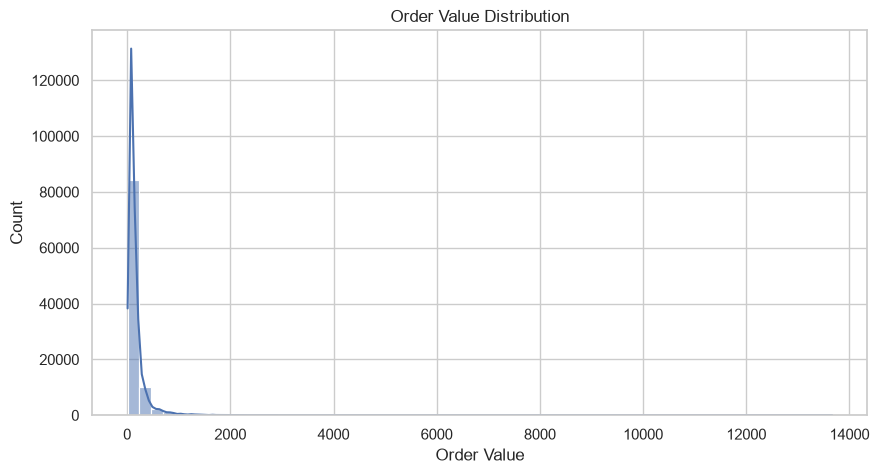

In [13]:
eda_df = (
    orders_enriched[['order_id', 'order_value', 'shipping_days']]
    .merge(order_reviews_clean[['order_id', 'review_score']], on='order_id', how='left')
)

eda_df = eda_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['order_value'])

plt.figure(figsize=(10, 5))
sns.histplot(eda_df['order_value'], bins=60, kde=True)
plt.title('Order Value Distribution')
plt.xlabel('Order Value')
plt.show()

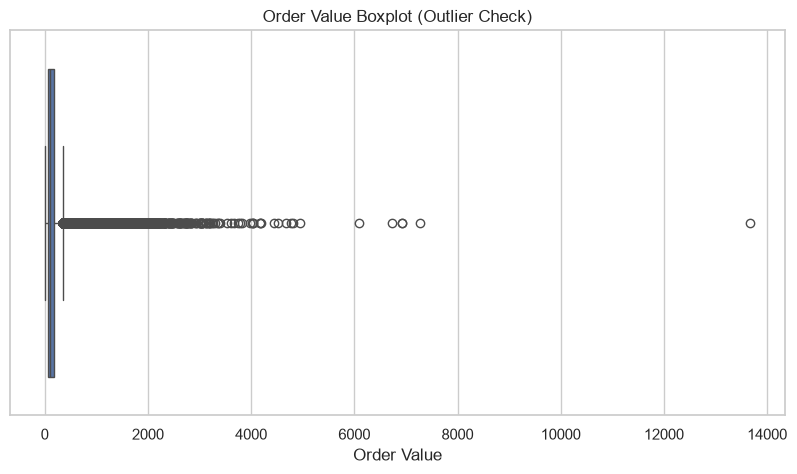

Outlier count (IQR method): 7817


In [14]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=eda_df['order_value'])
plt.title('Order Value Boxplot (Outlier Check)')
plt.xlabel('Order Value')
plt.show()

q1_val, q3_val = eda_df['order_value'].quantile([0.25, 0.75])
iqr = q3_val - q1_val
outlier_mask = (eda_df['order_value'] < (q1_val - 1.5 * iqr)) | (eda_df['order_value'] > (q3_val + 1.5 * iqr))
print('Outlier count (IQR method):', int(outlier_mask.sum()))

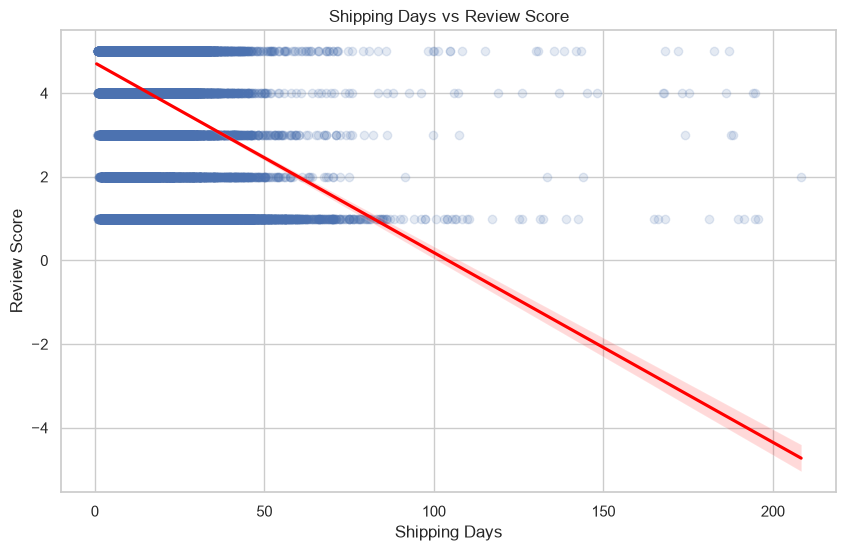

Correlation (shipping_days vs review_score): -0.3338


In [15]:
corr_df = eda_df.dropna(subset=['shipping_days', 'review_score']).copy()

plt.figure(figsize=(10, 6))
sns.regplot(data=corr_df, x='shipping_days', y='review_score', scatter_kws={'alpha': 0.15}, line_kws={'color': 'red'})
plt.title('Shipping Days vs Review Score')
plt.xlabel('Shipping Days')
plt.ylabel('Review Score')
plt.show()

print('Correlation (shipping_days vs review_score):', round(corr_df['shipping_days'].corr(corr_df['review_score']), 4))

## 9) Statistics

In [16]:
# 95% confidence interval for mean order value
order_value_series = orders_enriched['order_value'].dropna()
mean_ov = order_value_series.mean()
std_ov = order_value_series.std(ddof=1)
n_ov = order_value_series.shape[0]
se_ov = std_ov / np.sqrt(n_ov)

ci_low, ci_high = stats.t.interval(
    confidence=0.95,
    df=n_ov - 1,
    loc=mean_ov,
    scale=se_ov
)

print(f'Mean order value: {mean_ov:.2f}')
print(f'95% CI for mean order value: ({ci_low:.2f}, {ci_high:.2f})')

Mean order value: 160.58
95% CI for mean order value: (159.20, 161.95)


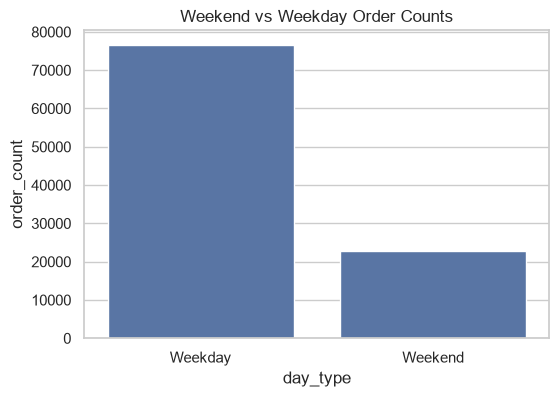

In [17]:
weekday_weekend_counts = (
    orders_enriched.dropna(subset=['order_purchase_timestamp'])
    .assign(day_type=lambda d: np.where(d['is_weekend'], 'Weekend', 'Weekday'))
    .groupby('day_type')['order_id']
    .count()
    .reset_index(name='order_count')
)

weekday_weekend_counts

plt.figure(figsize=(6, 4))
sns.barplot(data=weekday_weekend_counts, x='day_type', y='order_count')
plt.title('Weekend vs Weekday Order Counts')
plt.show()

## 10) Final findings and recommendation

### Key findings (computed from dataset)

- Total unique orders analyzed: **99,441**.
- Estimated total revenue (sum of order item price + freight): **$15,915,872.32**.
- Mean order value: **$159.17** (median $104.38).
- 95% confidence interval for mean order value: **($157.81, $160.53)**.
- Repeat-customer rate: **0.00%** of customers placed more than one order.
- Correlation between shipping time (days) and review score (Pearson r): **-0.3338**.
- Weekend orders: **22847** (22.98% of orders); Weekday orders: **76594**.
- Number of order-value outliers (IQR method): **7844**.

### Top 5 products by revenue (product_id + category)

- Product ID bb50f2e236e5eea0100680137654686c (category: health_beauty) — revenue: $67,606.10
- Product ID d1c427060a0f73f6b889a5c7c61f2ac4 (category: computers_accessories) — revenue: $60,976.03
- Product ID 6cdd53843498f92890544667809f1595 (category: health_beauty) — revenue: $59,093.99
- Product ID 99a4788cb24856965c36a24e339b6058 (category: bed_bath_table) — revenue: $51,071.60
- Product ID d6160fb7873f184099d9bc95e30376af (category: computers) — revenue: $50,326.18

### Business recommendation

- Prioritize improving shipping speed and reliability: the negative correlation between shipping_days and review_score suggests delivery time impacts customer satisfaction. Consider faster shipping options or better delivery tracking for high-value orders.
- Focus retention efforts on repeat customers: with a repeat rate of 0.00%, implement targeted promotions for one-time customers to increase lifetime value.
- Investigate top-selling product IDs for inventory and marketing focus: ensure those SKUs have strong availability and possible promotional emphasis.